In [1]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
import sys
sys.path.append("..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

from src.data_pipeline import encode_labels, get_class_weights, make_datasets
from src.models.cnn_model import build_efficientnet
from src.train import get_callbacks

In [2]:
# =========================
# CELL 2: LOAD DATA WITH NOTEBOOK-SAFE PATHS
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["filepath"] = train_df["filepath"].str.replace(
    "data/processed/train", "data/raw/train", regex=False
)
val_df["filepath"] = val_df["filepath"].str.replace(
    "data/processed/validation", "data/raw/validation", regex=False
)

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (4106, 4)
Validation shape: (0, 4)


,filepath,label,split,full_path
0,data/raw/train/BrownSpot/brown_spot434.jpg,BrownSpot,train,..\data/raw/train/BrownSpot/brown_spot434.jpg
1,data/raw/train/leaf_blast/leaf_blast777.jpg,leaf_blast,train,..\data/raw/train/leaf_blast/leaf_blast777.jpg
2,data/raw/train/rice_hispa/rice_hispa919.jpg,rice_hispa,train,..\data/raw/train/rice_hispa/rice_hispa919.jpg
3,data/raw/train/rice_hispa/rice_hispa291.jpg,rice_hispa,train,..\data/raw/train/rice_hispa/rice_hispa291.jpg
4,data/raw/train/BrownSpot/brown_spot90.jpg,BrownSpot,train,..\data/raw/train/BrownSpot/brown_spot90.jpg


In [3]:
# =========================
# CELL 3: ENCODE LABELS AND BUILD DATASETS
# =========================
y_train, y_val, label_encoder, class_names = encode_labels(train_df, val_df)
class_weights = get_class_weights(y_train)
train_ds, val_ds = make_datasets(train_df, val_df, y_train, y_val)

print("Classes:", class_names)
print("Class weights:", class_weights)

Classes: ['BrownSpot' 'Healthy' 'leaf_blast' 'rice_hispa']
Class weights: {0: 0.8669763513513513, 1: 3.279552715654952, 2: 0.7128472222222222, 3: 0.8781009409751924}


In [4]:
# =========================
# CELL 4: BUILD MODEL
# =========================
model, base_model = build_efficientnet(len(class_names))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [5]:
# =========================
# CELL 5: CALLBACKS
# =========================
model_path = "../experiments/results/best_efficientnetb0.keras"
callbacks = get_callbacks(model_path)
callbacks

In [6]:
# =========================
# CELL 6: FIRST TRAINING PHASE
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.2872 - loss: 1.8982

c:\Users\franc\OneDrive\Desktop\Rice-Leaf-Disease-Detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
c:\Users\franc\OneDrive\Desktop\Rice-Leaf-Disease-Detection\venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\franc\OneDrive\Desktop\Rice-Leaf-Disease-Detection\venv\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
c:\Use


Epoch 1: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.3690 - loss: 1.6356 - learning_rate: 1.0000e-04
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5403 - loss: 1.1520
Epoch 2: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 34s 259ms/step - accuracy: 0.5567 - loss: 1.0719 - learning_rate: 1.0000e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6144 - loss: 0.9274
Epoch 3: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 256ms/step - accuracy: 0.6352 - loss: 0.8789 - learning_rate: 1.0000e-04
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.6690 - loss: 0.7779
Epoch 4: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 33s 253ms/step - accuracy: 0.6836 - loss: 0.7284 - learn

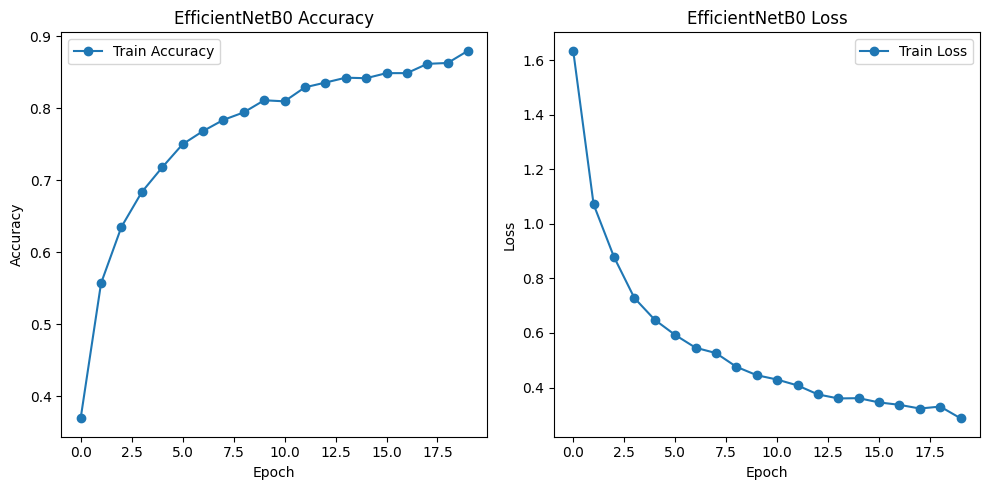

In [7]:
# =========================
# CELL 7: FIRST TRAINING PHASE LEARNING CURVES
# =========================
plt.figure(figsize=(10, 5))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history.get("accuracy", []), marker='o', label="Train Accuracy")

if "val_accuracy" in history.history:
    plt.plot(history.history["val_accuracy"], marker='o', label="Validation Accuracy")

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history.get("loss", []), marker='o', label="Train Loss")

if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], marker='o', label="Validation Loss")

plt.title("EfficientNetB0 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
# =========================
# CELL 8: FINE-TUNING
# =========================
base_model.trainable = True

for layer in base_model.layers[:-150]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=history.epoch[-1] + 1,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 21/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.6427 - loss: 0.9294
Epoch 21: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 93s 614ms/step - accuracy: 0.6829 - loss: 0.8359 - learning_rate: 1.0000e-05
Epoch 22/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.7675 - loss: 0.6050
Epoch 22: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 78s 601ms/step - accuracy: 0.7720 - loss: 0.5804 - learning_rate: 1.0000e-05
Epoch 23/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.7871 - loss: 0.5104
Epoch 23: finished saving model to ../experiments/results/best_efficientnetb0.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 77s 592ms/step - accuracy: 0.8064 - loss: 0.4863 - learning_rate: 1.0000e-05
Epoch 24/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.8350 - loss: 0.4188
Epoch 24: finished saving model to ../experiments/results/best_efficientne

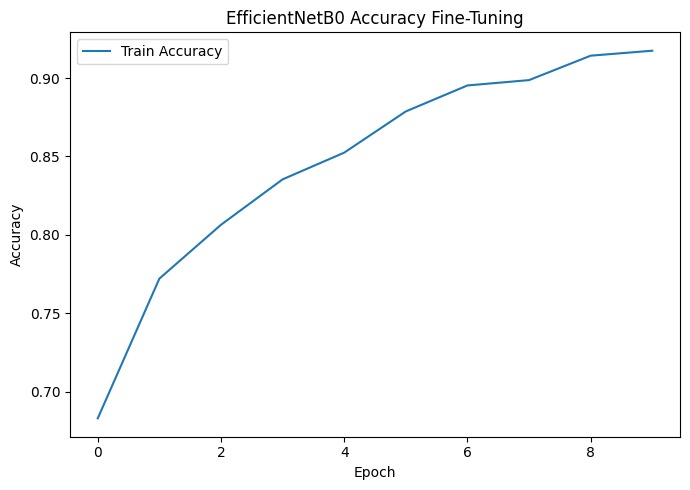

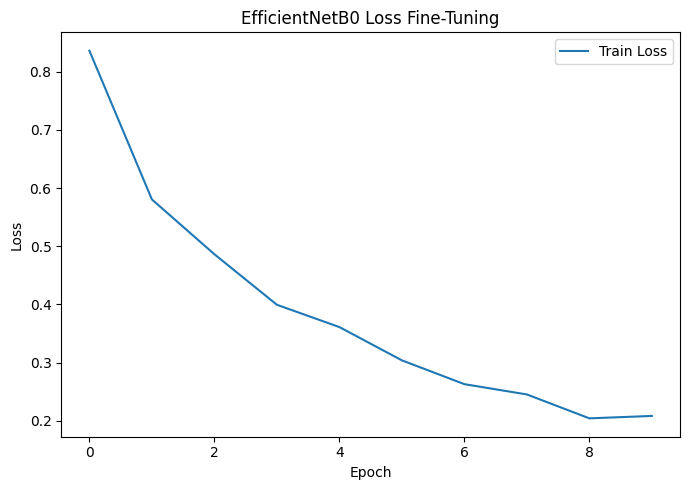

In [9]:
# =========================
# CELL 9: FINE-TUNING LEARNING CURVES
# =========================
plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history.get("accuracy", []), label="Train Accuracy")

if "val_accuracy" in fine_tune_history.history:
    plt.plot(fine_tune_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("EfficientNetB0 Accuracy Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(fine_tune_history.history.get("loss", []), label="Train Loss")

if "val_loss" in fine_tune_history.history:
    plt.plot(fine_tune_history.history["val_loss"], label="Validation Loss")

plt.title("EfficientNetB0 Loss Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# =========================
# CELL 10: LOAD SAVED TRAINING HISTORY
# =========================
history_path = Path("../experiments/logs/training_history.json")

if history_path.exists():
    with open(history_path, "r") as f:
        saved_history = json.load(f)

    history_df = pd.DataFrame(saved_history)
    history_df.head()
else:
    print("No saved training history found.")

In [11]:
# =========================
# CELL 11: LOAD FINAL EVALUATION RESULTS
# =========================
eval_csv_path = Path("../experiments/results/eval_results.csv")
eval_json_path = Path("../experiments/results/eval_metrics.json")

if eval_csv_path.exists():
    eval_results_df = pd.read_csv(eval_csv_path)
    display(eval_results_df)
else:
    print("Evaluation CSV not found.")

if eval_json_path.exists():
    with open(eval_json_path, "r") as f:
        eval_metrics = json.load(f)

    print("Evaluation Metrics:")
    print(eval_metrics)
else:
    print("Evaluation JSON not found.")

,Model,Accuracy,Macro-F1
0,EfficientNetB0,0.988289,0.982744


Evaluation Metrics:
{'accuracy': 0.9882888744307091, 'macro_f1': 0.9827442306957619}


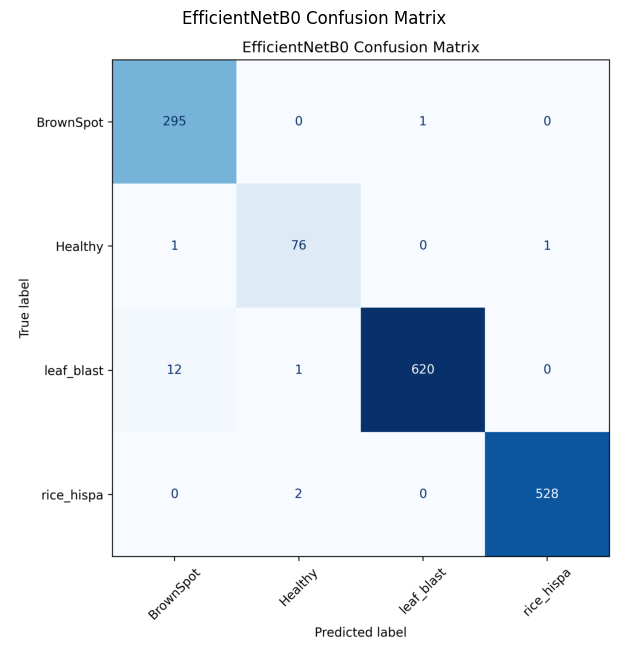

In [12]:
# =========================
# CELL 12: DISPLAY CONFUSION MATRIX IMAGE
# =========================
conf_matrix_path = Path("../experiments/results/confusion_matrix.png")

if conf_matrix_path.exists():
    img = plt.imread(conf_matrix_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("EfficientNetB0 Confusion Matrix")
    plt.show()
else:
    print("Confusion matrix image not found.")

In [13]:
# =========================
# CELL 13: SHORT SUMMARY
# =========================
print("Summary:")
print("- EfficientNetB0 was utilized as the CNN backbone with transfer learning.")
print("- The model was trained using class weights, validation data, and fine-tuning to improve generalization.")
print("- Both training and validation performance were evaluated using accuracy and loss metrics.")
print("- Final evaluation results, including metrics and confusion matrix, are presented above.")

Summary:
- EfficientNetB0 was utilized as the CNN backbone with transfer learning.
- The model was trained using class weights, validation data, and fine-tuning to improve generalization.
- Both training and validation performance were evaluated using accuracy and loss metrics.
- Final evaluation results, including metrics and confusion matrix, are presented above.
